# Analytical Statistical Assessment

## The Binomial Test: 

Testing hypotheses for a single binary variable

The first test we will look at is the binomial test. We use it when we want to test hypotheses concerning one binary variable.

### Tossing a Coin

To develop the binomial test, we consider an abstract example, namely testing whether a coin is biased.

We first introduce some notation. Let:

1. $n$ : the total number of independent random tosses of the coin.

2. $X_i$ : the value of the i-th toss, with 
    * $X_i = 1$ if the result is head
    * $X_i = 0$ if the result is tail

3. $\mu = E(X_i) = p(X_i = 1)$ : the probability of getting a head.

We assume that the $X_i$ to be i.i.d

As we will see again and again in this chapter, to develop a statistical test we require three ingredients:

* The Null Hypothesis $H_0$ (and a suitable alternative hypothesis $H_1$
, either one or two-sided)

* A Test Statistic $T$

* The distribution of this test statistic under the null hypothesis, $p(T|H_0)$

(Note that in permutation testing the sampling procedure simulated the distribution of our test statistic under the null hypothesis.)



To test whether a coin is biased, our null hypothesis is that the coin is fair:

$H_0: \mu = 0.5$

And our alternative is that it is biased (either towards heads or tails):

$H_1: \mu \neq 0.5$

As test statistic, we will use the total number of heads, i.e. $T = \sum_i X_i$

### A single coin toss

Now assume, for the sake of argument, we toss the coin only once $(n = 1)$

and get a head $(T_{obs} = 1)$. 

What is the two-sided $P$-value in this case?

In this scenario, there are of course only 2 possible outcomes. Either we get one head or we get one tail. Under the null hypothesis, both outcomes are equally likely. Therefore, the distribution of the test statistic under the null hypothesis is given by:



$p(T = 0 | H_0) = 0.5 = p(T = 1 | H_0)$

The two-sided $P$-value is then given by:

$P = 2\min\{ \quad p(T \leq T_{obs} | H_0), \quad p(T \geq T_{obs} | H_0)\quad\}$

$2 * 0.5 = 1$

Thus, if we only performed a single coin toss, the data cannot provide sufficient evidence for rejecting the null hypothesis in a two-sided test.

This, of course, does not allow us to conclude that the null hypothesis is correct. 

<u>After all, we could have generated the same data with a coin that has heads on both sides, for which the null hypothesis clearly does not hold.</u>

Another way to look at it, is to state that the data does not provide sufficient evidence to conclude that the coin is biased.

### Several Coin Toss

Now assume we toss the coin $n > 1$ and observe $T_{obs}$ heads. 

What is the distribution of the test statistic under the null hypothesis now?



We can easily simulate data under this assumption in Python by sampling from `Bernoulli` distribution `n` times. 

The probability for each outcome can be provided with the `prob` argument. 

Here is one such simulation of $n=10$
 trials under the null hypothesis $\mu = 0.5$
.

In [83]:
from scipy.stats import bernoulli

n = 10
prob = 0.5

x = bernoulli.rvs(prob, size = n)
x 

array([0, 1, 0, 1, 0, 1, 1, 1, 1, 1])

Our test statistic $T$ is the sum of heads:

In [84]:
t = sum(x)
print(t)

7


The probability of observing $T$
 heads after tossing a coin $n$
 times is given by the binomial distribution, which is the binomial coefficient, i.e. the number of possible sequences of events with the same total number of heads, times the probability of a given sequence, which is itself the product of the probability of each individual realization (i.i.d. assumption):

$p(T|n,\mu) = \binom{n}{T}\mu^T(1-\mu)^{n-T}$

Hence, assuming the null distribution is true, we get that:

$p(T|n,\mu = 0.5) = \binom{n}{T}(0.5)^n$

This is implemented in `scipy.stats` library in Python with the function `binom`.

In [85]:
from scipy.stats import binom

binom.pmf(k = t, n=n, p=0.5)

np.float64(0.11718750000000004)

We recall that the $P$-value is defined as the probability, under the null hypothesis, of observing a test statistic as or more extreme as the one we actually observed.

Since we just want to know whether the coin is biased, and do not care in which direction, we need a two sided 
$P$-value. 

This is given by 

$P = 2\min\{\quad p(T \leq T_{obs}| H_0), \quad p(T \geq T_{obs} | H_0)\quad\}$

$=2\min\{\quad \sum_{T \leq T_{obs}} \binom{n}{T}(0.5)^n, \quad \sum_{T \geq T_{obs}} \binom{n}{T}(0.5)^n \}$


<img src= 'images/Analytical Statistical Assessment.png' width = 600>

if $T_{obs} = 7$,

One can compute the smaller of the two terms which is here $\sum_{T \geq 7} \binom{n}{T}(0.5)^n$ as the figure suggests and corresponds to the right tail marked in red in figure.

This equals to $1-\sum_{T < 6} \binom{n}{T}(0.5)^n$ and is obtained in Python with:


In [86]:
1 - binom.cdf(k= 6, n= n, p= 0.5)

np.float64(0.171875)

Hence the two-sided $P$-value is twice this value, yielding:

In [87]:
2 * (1 - binom.cdf(k= 6, n= n, p= 0.5))

np.float64(0.34375)

Altogether we have $P = 0.34375$. 

We do not reject the null hypothesis that the coin is fair at a significance level of $0.05$.

### Computing a binomial test with Python

In actual applications, we use the `scipy.stats.binomtest` function of Python. For the example above, we do:

In [88]:
from scipy.stats import binomtest

print(t)
binomtest(t, n, p = 0.5, alternative= 'two-sided')

7


BinomTestResult(k=7, n=10, alternative='two-sided', statistic=0.7, pvalue=0.34375)

We see that the function has three parameters, which correspond to $T_{obs}$
, $n$
and the $\mu$ 
under $H_0$
respectively (R calls the last one $p$
). 

Additionally, we can specify whether we want a two-sided or one-sided test using the “alternative” option. 

The options are 

- “two-sided”, 
- “greater” 
- “less”.



We also see that the function returns an object, which summarizes the test that was performed. If we want to just get the 
$p$-value, we do:

In [89]:
test = binomtest(t, n, p = 0.5, alternative= 'two-sided')
test.pvalue

np.float64(0.34375)

---

## Fisher’s exact test

Testing the association between two binary variables

Suppose we are trying to determine whether people who smoke are more likely to develop severe symptoms if they contract a respiratory virus than non-smokers. For this we collect data from $n = 110$ randomly sampled patients.

Assume we receive the following table as a result:

In [90]:
import pandas as pd
import numpy as np

smoker_df = pd.DataFrame({
    'Severe' : [10, 10],
    'Mild' : [20, 70]
}, index= ['Smoker', 'Nonsmoker'])

smoker_df

,Severe,Mild
Smoker,10,20
Nonsmoker,10,70


We see that $30\%$ of the patients were smokers, whereas $80\%$ were non-smokers. 

We further observe that only $\frac{1}{8}$ th of non-smokers developed severe symptoms, 

whereas $\frac{1}{3}$ rd of the smokers did.

The <b>odds</b> are 1:2 (10 severe versus 20 mild) for infected smokers to develop severe symptoms against 1:7 (10 severe versus 70 mild) for non-smokers. 

Hence, these data suggests that there is relationship between smoking and developing severe symptoms, with odds about 3.5 times higher for smokers than for non-smokers.

Once again, we need to make sure that these results are statistically significant. We cannot use the binomial test, because now we are not just considering one binary variable, but rather we are investigating the relationship between two binary variables.

-----

### Hypergeometric distribution

It is enlightening to approach first this problem with permutation testing

To this end, one shall first consider the underlying, not aggregated, dataset of individual cases. Such tidy dataset, where one row is one patient and each column one variable, would have the following structure:

In [91]:
patient = ['patient_' + str(i) for i in range(1,110+1)]
results = [['yes','severe'] for _ in range(10)] + [['yes','mild'] for _ in range(20)] + [['no','severe'] for _ in range(10)] + [['no','mild'] for _ in range(70)]

results = np.random.permutation(results)
results_smoker = [r[0] for r in results]
results_symptom = [r[1] for r in results]

patients_df = pd.DataFrame({
    'Patient' : patient,
    'Smoker' : results_smoker,
    'Symptoms' : results_smoker
})

patients_df.head()

,Patient,Smoker,Symptoms
0,patient_1,no,no
1,patient_2,yes,yes
2,patient_3,no,no
3,patient_4,yes,yes
4,patient_5,no,no


For permutation testing, the null hypothesis is the <u>independence of the Smoker and the Symptoms variables.</u> 

With permutation testing, data under the null hypothesis are simulated by permuting values in one column (say “Symptoms”) keeping the order of the other column (say “Smoker”) fixed. 

For each permutation, we get a different 2x2 contingency table which we will denote as:

In [92]:
result_table_general = pd.DataFrame({
    'Severe': ['a', 'c', 'a+c'],
    'Mild': ['b', 'd', 'b+d'],
    'Row Total': ['a+b', 'c+d', 'n= a+b+c+d']
}, index= ['Smoker', 'Non-smoker', 'Column total'])

result_table_general

,Severe,Mild,Row Total
Smoker,a,b,a+b
Non-smoker,c,d,c+d
Column total,a+c,b+d,n= a+b+c+d


Note that any such permutation keeps the size of the dataset, the total number of smokers as well as the total number of patients with severe symptoms constant. We say that these permutations keep the margins (row and column totals) of the contingency table constant.

Consequently, one cell in the 2x2 contingency table suffices to characterize the entire table because all other counts can then be derived using the margins. Therefore, we can use any cell in the table as test statistic, but we usually use $a$
, i.e. the upper left corner.

The good news is that the distribution of $a$
under the null hypothesis (i.e. its frequency among all possible distinct permutations) can be exactly computed. It is given by the `hypergeometric distribution`:

Think of the n individuals split into two types (by columns):

* <b>Type1</b> 'Col1': $a+c$ individuals,
* <b>Type2</b> 'Col2': $b+d$ individuals,

Now you “draw” the individuals that will belong to Row 1, and Row 1 has fixed size $a+b$.

Under $H_0$ (no association), Row assignment is random given the margins, so Row 1 is like a simple random sample of size a+b from the n individuals.

Let `K` be “how many Col 1 individuals end up in Row 1”. Then:

$p(K = a | H_0) = \frac{\binom{a+c}{a} \binom{b+d}{b}}{\binom{n}{a+b}}$

= $\frac{(a+c)!}{a!c!} \frac{(b+d)!}{b!d!} / {\frac{n!}{(a+b)! (c+d)!}}$

= $\frac{(a+c)! \quad (b+d)! \quad (a+b)!  \quad (c+d)!}{a!\quad b!\quad c! \quad d! \quad n!}$

### Fisher’s exact test

Using the hypergeometric distribution, we can now derive $P$-values, in the same way as we did before, namely by summing the probability of observing a test statistic as, or more, extreme as the one we observed. So, to compute the one-sided 
$P$-value, we would use:

$P = \sum_{i \geq a} p(k = i | H_0)$

This is called Fisher’s exact test.

### In Python 

In Python, we can perform Fisher’s exact test using `fisher_exact` function from `scipy.stats`. This requires a contingency table as input. For our contingency table, we get:

In [93]:
from scipy.stats import fisher_exact

tst = fisher_exact(smoker_df, alternative= 'greater')
tst

SignificanceResult(statistic=np.float64(3.5), pvalue=np.float64(0.014809450686175531))

The one-sided 
$P$-value is $0.014809450686175531$. At the level $\alpha = 0.05$
, one would therefore reject the null hypothesis of independence of symptom severity and smoking status.

As for the binomial test, the $P$-value can be extracted with `.pvalue`.

-----------

## Quantitative & Binary 

To formalize this problem, we first note that the binary variable splits the quantitative data into two groups. 

Let $X = x_1, ..., x_{n_x}$ 
be the quantitative data of the first group (i.e. the growth rates of yeast strains with lab strain genotype), 

and  $Y = y_1, ..., y_{n_y}$
be the quantitative data of the second group (i.e. the growth rates of yeast strains with wild isolate genotype).

### T-Test

The first test statistic we will look at is Student’s $t$, defined as:

$t = c \frac{\bar{x} - \bar{y}}{s}$

where 

* $\bar{x}$ and $\bar{y}$ is the sample means of $X$ and $Y$ respectively.

* $s$ is the pooled standard deviation

* $c$ is a constant that depends on the sample size of each group. In details 

$\begin{aligned}
\bar{x} &= \frac{1}{n_x} \sum_i x_i \\
\bar{y} &= \frac{1}{n_y} \sum_i y_i \\
s &= \sqrt{
\frac{
\sum_i (x_i - \bar{x})^2 + \sum_i (y_i - \bar{y})^2
}{
n_x + n_y - 2
}
} \\
c &= \sqrt{
\frac{n_x n_y}{n_x + n_y}
}
\end{aligned}$

While the details can always be looked up, understanding Equation Equation 8.2 is useful. Intuitively, the 
$t$-statistic compares, up to the constant $c$
, the “signal” of group difference, namely the estimated difference of the means of the two groups, to the “noise”, i.e. how uncertain we are about our estimate of this difference. This “noise” in our estimate is itself the ratio of the typical variations within the groups ($s$
) over a term capturing the sample size ($c$
). One can thus interpret it as a signal-to-noise ratio. If the $t$
-statistic is large, then we see a clear difference in means. By contrast, if the $t$
-statistic is small, then the difference in means is not large compared to the noise. Larger sample size (more data) or larger between-group differences compared to within-group differences lead to larger $t$
-statistics.

### Student's t-distribution

Before we can derive the distribution of this test statistic under the null hypothesis, we need to make some additional assumptions about the data, namely:

* All oberservations $x_1, ..., x_{n_x}, y_1, ..., y_{n_y}$ are independent of each other.

* We assume that $X$ and $Y$ both follow Gaussian distributions

* $X$ and $Y$ have the same unknown variance 

A consequence of these assumptions is that our null hypothesis simplifies. If both $X$
and $Y$
are Gaussian with the same variance, the only way the two groups can differ is if the Gaussians have different means.

Therefore, the null hypothesis is that the expectations are equal:

$H_0: E(X) = E(Y)$

Under $H_0$, our test statistic $t$ follow a Student's t-distribution with

$v = n_x + n_y - 2$ degrees of freedom (the degrees of freedom 
 is the parameter of Student’s t-distribution)

Below Figure shows the shape of Student’s $t$-distribution for different degrees of freedom .

https://www.wikiwand.com/en/articles/Student%27s_t-distribution

<img src = 'images/Analytical Statistical Assessment (1).png' width = 600>

### Student’s t-test in Python

Let’s apply Student’s t-test to yeast dataset dt containing growth rate for the marker of interest for both lan strain and wild isolate:

In [94]:
df = pd.DataFrame({
    "growth_rate": [4.17, 5.58, 5.18, 6.11, 4.50],
    "genotype": ["Lab strain", "Wild isolate", "Wild isolate", "Lab strain", "Lab strain"]
})

df

,growth_rate,genotype
0,4.17,Lab strain
1,5.58,Wild isolate
2,5.18,Wild isolate
3,6.11,Lab strain
4,4.50,Lab strain


In Python we can perform a t-test using the function `ttest_ind` from `scipy.stats`, that requires two samples as an input. Function returns an object containing pvalue, test statistic and degree of freedom.

In [95]:
from scipy.stats import ttest_ind

test_res = ttest_ind(
    a = df[df['genotype'] == 'Lab strain']['growth_rate'].values,
    b = df[df['genotype'] == 'Wild isolate']['growth_rate'].values,
    nan_policy= 'omit'
)

test_res

TtestResult(statistic=np.float64(-0.5753645432290957), pvalue=np.float64(0.6053644876893429), df=np.float64(3.0))

Note that the function reports the $t$
-statistic and the degrees of freedom, in addition to the $p$
-value. 

Moreover, our data contains `nan` values, so we need to tell `ttest_ind` fundtion to ignore them and not include into calculation (by setting flag nan_policy = 'omit'); otherwise returned values will be all nans.

---------

### Welch's Test (Unequal Variance)

* In practice, one does not assume equal variances and this leads to slightly different degree. Such test is known as `Welch’s test`.

* By defualt <u>ttest_ind assumes equal variances</u> and runs classical $t$ 
-test. 

* To run Welch’s test in Python we can use ttest_ind with parameter <b>equal_var=False</b>

In [96]:
test_res = ttest_ind(
    a = df[df['genotype'] == 'Lab strain']['growth_rate'].values,
    b = df[df['genotype'] == 'Wild isolate']['growth_rate'].values,
    equal_var= False,
    nan_policy= 'omit'
)
test_res.pvalue

np.float64(0.5362166068095858)

### Wilcoxon Rank-Sum Test

An alternative to the t-test for non-Gaussian data


As we saw, the $t$
-test assumes the data follows a specific distribution, namely a Gaussian. There are many situations where this is reasonable, but in general we cannot guarantee that this assumption holds. Using the $t$
-test if the data is not normal can lead to wrong conclusions. For instance, distributions that have heavier tails that the Gaussian can lead to false null hypothesis rejections as sample mean differences can seem to be surprisingly large

The Wilcoxon Rank-Sum test is a popular alternative to the t-test. It makes very few assumptions about the data, namely that:

* All observations $x_1,..., x_{n_x}, y_1, ..., y_{n_y}$  are independent of each other

* The responses are ordinal, i.e. we can rank them

Specifically, we assume that under the null hypothesis $H_0$
, the probability of an observation from the population X exceeding an observation from the second population Y equals the probability of an observation from Y exceeding an observation from X:

$H_0: p(X > Y) = P(Y > X)$

In other words, if we randomly take observations $x \in X$
 and $y \in Y$
, we would expect that $x > y$
 occurs as often as $y > x$
 (ignoring ties).

A stronger null hypothesis commonly used is “The distributions of both populations are equal” which implies the previous hypothesis.

For a two-sided test, the alternative hypothesis is “the probability of an observation from the population X exceeding an observation from the second population Y is different from the probability of an observation from Y exceeding an observation from X: $p(X > Y) \neq p(Y > X)$
.” 

The alternative may also be stated in terms of a one-sided test, for example: $p(X > Y) > p(Y > X)$
. This would mean that if we randomly take observations $x \in X$
 and $y \in Y$
, we would expect that $x > y$
 occurs more often than $y > x$ 
.

------

### The Mann-Whitney U statistic and the Wilcoxon rank-sum test

Consider first that we rank all observed values (and ignore ties), e.g.:

$x_5 < y_{10} < y_{12} < y_3 < x_4 < x_{17} < ...$

The idea of the Wilcoxon rank-sum test is that under the null hypothesis, the $x_i$
’s and $y_i$
’s should be well interleaved in this ranking.

In contrast, if say $X$
 tend to be smaller than $Y$
, then the $x_i$
’s will get lower ranks. The test statistics is therefore based on the sum of the ranks of the realizations of one the two variables.

Specifically, we define the quantity $U_x$ as:

$U_x = R_x - \frac{n_x (n_x + 1)}{2}$

where $R_x$ is the sum of the ranks of the $x_i$ ’s. 

Example: 

$R_x = 1 + 5 + 6 + ...$ ,and $n_x$ is the number of observations of set $X$.

The term $\frac{n_x(n_x + 1)}{2}$ (this is the famous Gauss sum) is a constant so that $U_x = 0$ when all the first values are from $X$.

$U_y$ is defined analogously.

The `Mann-Whitney U statistic` is defined as:

$U = \min\{U_x, U_y\}$

$P$-values are then based on the distribution of Mann-Whitney U statistic under the null hypothesis.

It combines tabulated values for small sample sizes and Central Limit Theorem approximation for large sample sizes (exploiting that the expectation and the variance of $U$
 under the null can be analytically derived)

----

### Wilcoxon rank-sum test in Python

In Python we can perform the `Wilcoxon rank-sum test` using the `mannwhitneyu` function from `scipy.stats` package, whose usage is analogous to the usage of `ttest_ind`:

In [97]:
from scipy.stats import mannwhitneyu

mannwhitneyu(
    x=df[df['genotype'] == 'Lab strain']['growth_rate'].values, 
    y=df[df['genotype'] == 'Wild isolate']['growth_rate'].values, 
    alternative='two-sided',
    nan_policy = 'omit' 
).pvalue

np.float64(0.8)

--------

### Why bother with the Wilcoxon rank-sum test?

The Wilcoxon rank-sum test makes less assumptions than the $t$
-test, <u>specifically because it does not require that the data follows a Gaussian distribution.</u> We will now see an example to illustrate this.

We construct a highly pathological example:

In [98]:
x1 = np.random.normal(loc = 10, scale= 1, size = 100)
x2_base = np.random.normal(loc = 5, scale = 1, size = 99)
x2 = np.append(x2_base, 500)

x2[-2:]

array([  6.84177218, 500.        ])

In [99]:
grp_tbl = pd.DataFrame({
    'group' : np.repeat(['group1','group2'], 100),
    'x': np.concatenate([x1,x2])
})

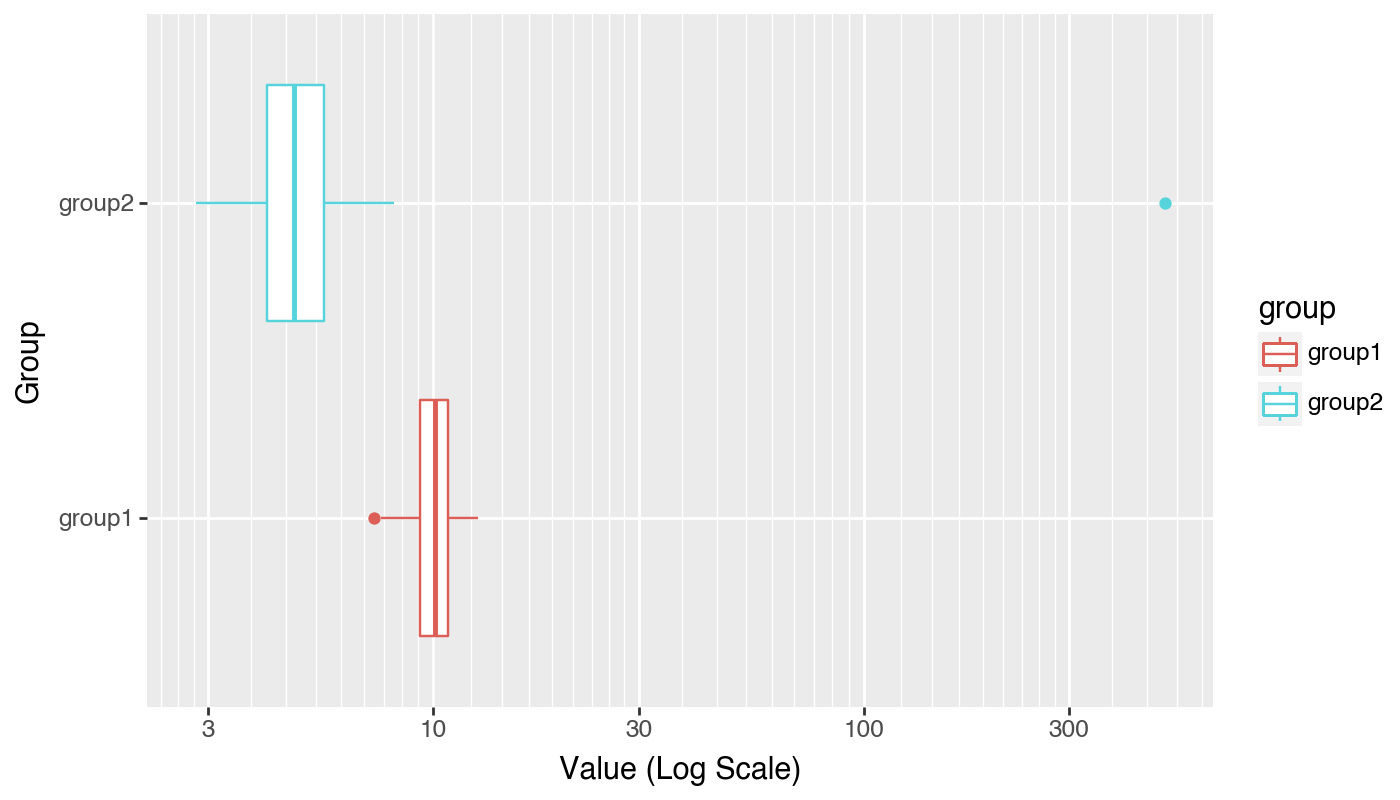

In [100]:
from plotnine import *

(
    ggplot(grp_tbl, aes(x= 'group', y = 'x', color = 'group'))+
    geom_boxplot()+
    coord_flip() +
    scale_y_log10() +
    theme(figure_size=(7,4)) +
    labs(y = 'Value (Log Scale)', x = 'Group')
)

In this example, the groups are sampled from normal distributions with a different mean. 

<u>However, we add a non-normal outlier to the second group, which ensures that the overall mean looks the same.</u>

Recall that, as a consequence of assuming that the data is Gaussian, the null hypothesis of the $t$ 
-test is that the difference in means is zero. There is no difference in means here, so the $t$
-test cannot reject the null hypothesis:

In [101]:
ttest_ind(x1, x2, equal_var=False).pvalue

np.float64(0.9668776213628809)

But clearly, these groups are overall quite different, and their means only appear similar due to this one outlier. The null hypothesis of the Wilcoxon rank-sum test is not about the means. Instead, the Wilcoxon rank-sum test uses the rank distribution, and in our example most observations of the second group will rank above the observations of the first. The one outlier will not affect the ranking much. Thus, the Wilcoxon rank-sum test will reject here:

In [102]:
mannwhitneyu(x1,x2, alternative='two-sided').pvalue

np.float64(5.987822313655892e-33)

This is a rather synthetic example, but the underlying point is very general: if we are unsure whether the distributional assumption is met, a test like the Wilcoxon rank-sum test will generally be more robust than a test making distributional assumptions like the 
-test. But do note that there is a flip side to this: if the data is indeed Gaussian, then the t-test will be more powerful (i.e. more sensitive in detecting violations of the null hypothesis) than the more generally applicable Wilcoxon rank-sum test.

-----
-----

## Two quantitative variables

The last scenario we will consider in this chapter concerns the dependence between two quantitative variables. 

That is, we assume we have quantitative data in the form of tuples $(X,Y)$:

$(x_1,y_1), ..., (x_n,y_n)$ and we want to see if knowing one of the values in such a tuple gives us information about the other one.

   x1235    y1    y2     y3    y5   x4    y4
0   10.0  8.04  9.14   7.46  9.82  8.0  6.58
1    8.0  6.95  8.14   6.77  5.56  8.0  5.76
2   13.0  7.58  8.74  12.74  9.51  8.0  7.71
3    9.0  8.81  8.77   7.11  5.45  8.0  8.84
4   11.0  8.33  9.26   7.81  9.72  8.0  8.47


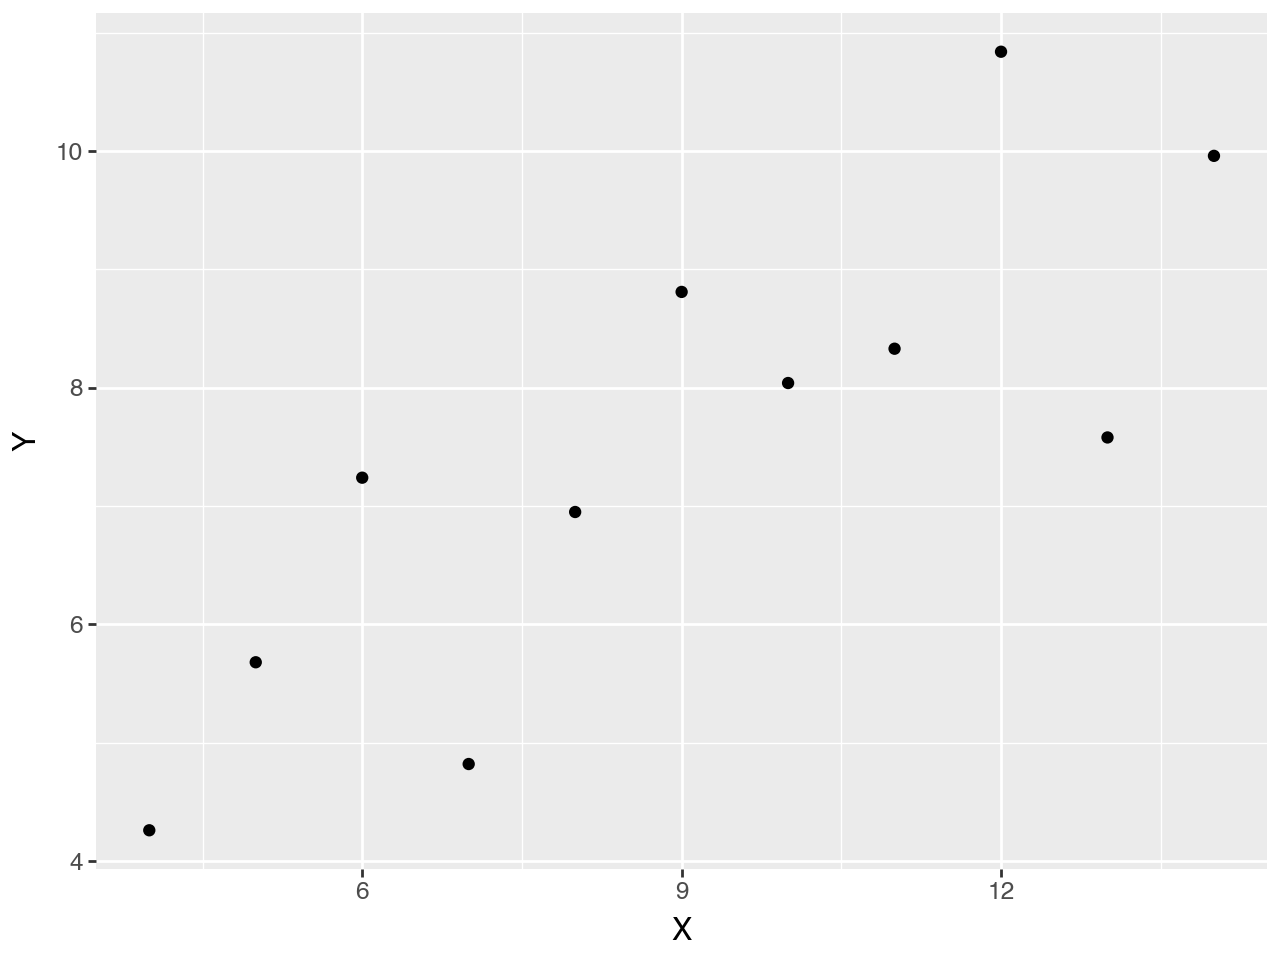

In [129]:
Anscombe_quintet = pd.read_csv('Datasets/Anscombe_quintet_data.csv')

print(Anscombe_quintet.head())

(
    ggplot(Anscombe_quintet, aes(x = 'x1235', y = 'y1')) + 
    geom_point() + 
    labs(x = 'X', y = 'Y')
)

Looking at the plot above, it sure seems that there is a positive relationship between $X$
 and $Y$
 in this data.

Specifically, if we know that $x_i$
 is relatively high, it seems that we can usually assume that $y_i$
 will be high too (and vice-versa). 

But once again, we need a test to prevent us from being fooled by randomness.

This means we again need null and alternative hypotheses, a test statistic and a distribution of the test statistic under the null hypothesis.

We will consider two different tests which are based on different notions of the concept of correlation.

### The Pearson Correlation Test

An important property is that when two variables $(X,Y)$ form a bivariate Gaussian distribution , their independence is equivalent to their population Pearson correlation coefficient $\rho_{X,Y} = 0$. This motivates for a Hypothesis test, called the Pearson correlation coefficient test.

#### Pearson’s Correlation Coefficient

The Pearson correlation coefficient test is based on the sample estimate of the population Pearson correlation coefficient, defined as:

$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2}\sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$

Let us look at the components of this. The numerator compares the deviation of the $x_i$
 and $y_i$
 to their respective means. Terms of the sum are positive if both $x_i$
 and $y_i$
 vary in the same direction (larger or lesser) compared to their mean and negative otherwise. 
 
 Hence, the numerator is largely positive when deviations from the means agree in direction, largely negative when they are opposite, and about 0 when deviations are independent of each other. More formally, the numerator is proportional to the sample covariance (See Appendix B). 
 
 The terms in the denominator is proportional to the individual sample standard deviations of $X$
 and $Y$. Hence, $r$
 compares how much the $X$
 and $Y$
 vary together to the product of how much they vary individually.

The Pearson correlation coefficient is symmetric. Moreover, it is invariant to affine transformations of the variables. It ranges from -1 to 1, where:

* $r = 1 \rarr$ $x$ and $y$ are perfectly linearly related with a positive slope

* $r = -1 \rarr$ $x$ and $y$ are perfectly linearly related with a negative slope

#### The Test

The assumptions of the Pearson correlation test are:

* $(X,Y)$ is a bivariate Gaussian distribution

* The observations $(x_i, y_i)$ are i.i.d.

The null hypothesis is that the two variables are statistically independent, which under the above assumptions amounts to state that:

$H_0: \rho_{(X,Y)} = 0$

The test statistic is given by:

$t = r\sqrt{\frac{n-2}{1-r^2}}$

Under $H_0$
, the test statistic $t$
 defined above follows a Student’s $t$
-distribution with degrees of freedom $n-2$
.

In Python one can run Pearson test using `pearsonr` function from `scipy.stats` to perform a Pearson correlation test. Thus function returns both p-value and statistic, which is pearson correlation between X and Y:

In [127]:
from scipy.stats import pearsonr

res = pearsonr(Anscombe_quintet['x1235'], Anscombe_quintet['y1'])

print(f'Statistic: {res.statistic}, P-Val: {res.pvalue}')

Statistic: 0.8164205163448396, P-Val: 0.002169628873078805


-----

### The Spearman Rank Correlation Test

Motivation:

Pearson’s correlation captures linear relationship between variables, which is quite restrictive. For instance, if one of the variables is in log-scale or quadratic scale, then the linear relationship is lost. Here is a constructed example:

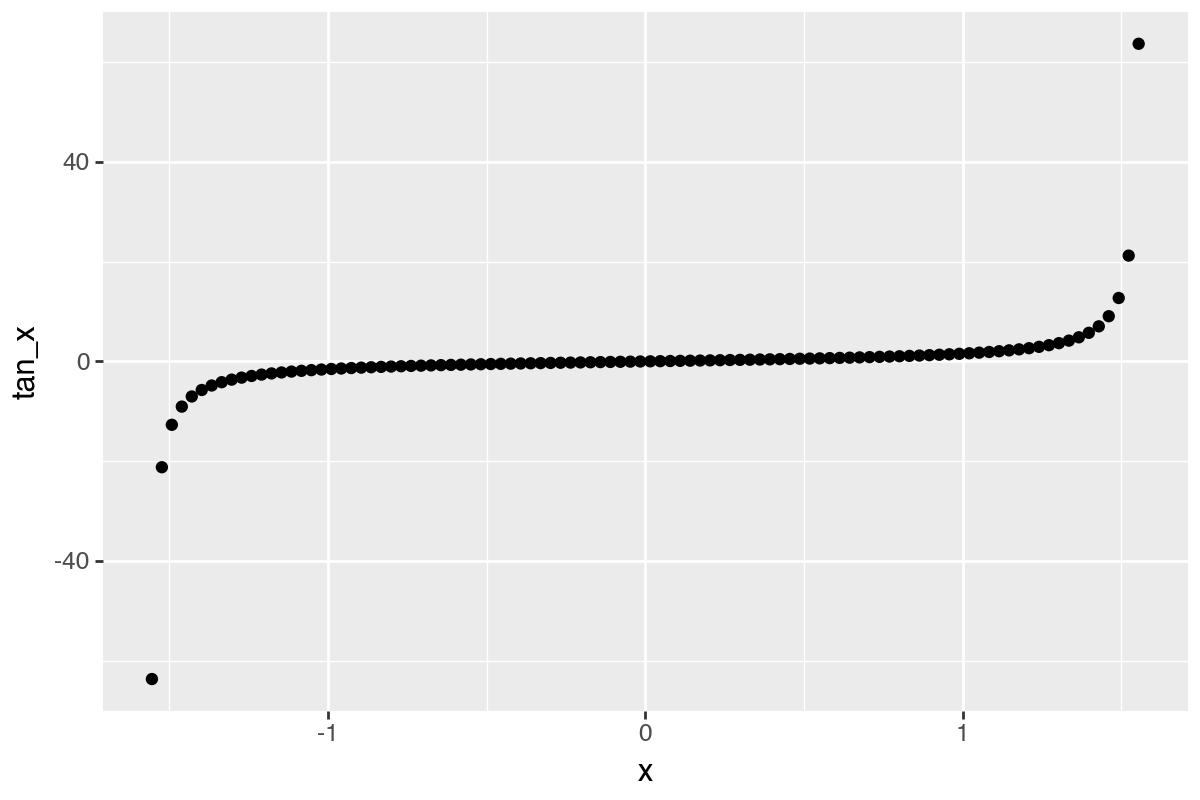

In [123]:
epsilon = 0.99
x = np.linspace(epsilon*np.pi * -0.5,epsilon* np.pi * 0.5, 100)
tan_x = np.tan(x)

df = pd.DataFrame({
    'x':x,
    'tan_x': tan_x
})

(
    ggplot(df, aes(x = 'x', y = 'tan_x')) +
    geom_point() +
    theme(figure_size= (6,4))
)

These two constructed variables relate exactly to each other by a monotonic relationship (the tangent function) 7. However their Pearson correlation is modest:

In [124]:
pearsonr(df['x'],df['tan_x']).statistic

np.float64(0.5242983456602679)

Conversely Pearson’ correlation can be excessively large in presence of outliers. Anscombe’s quartet provides an example:

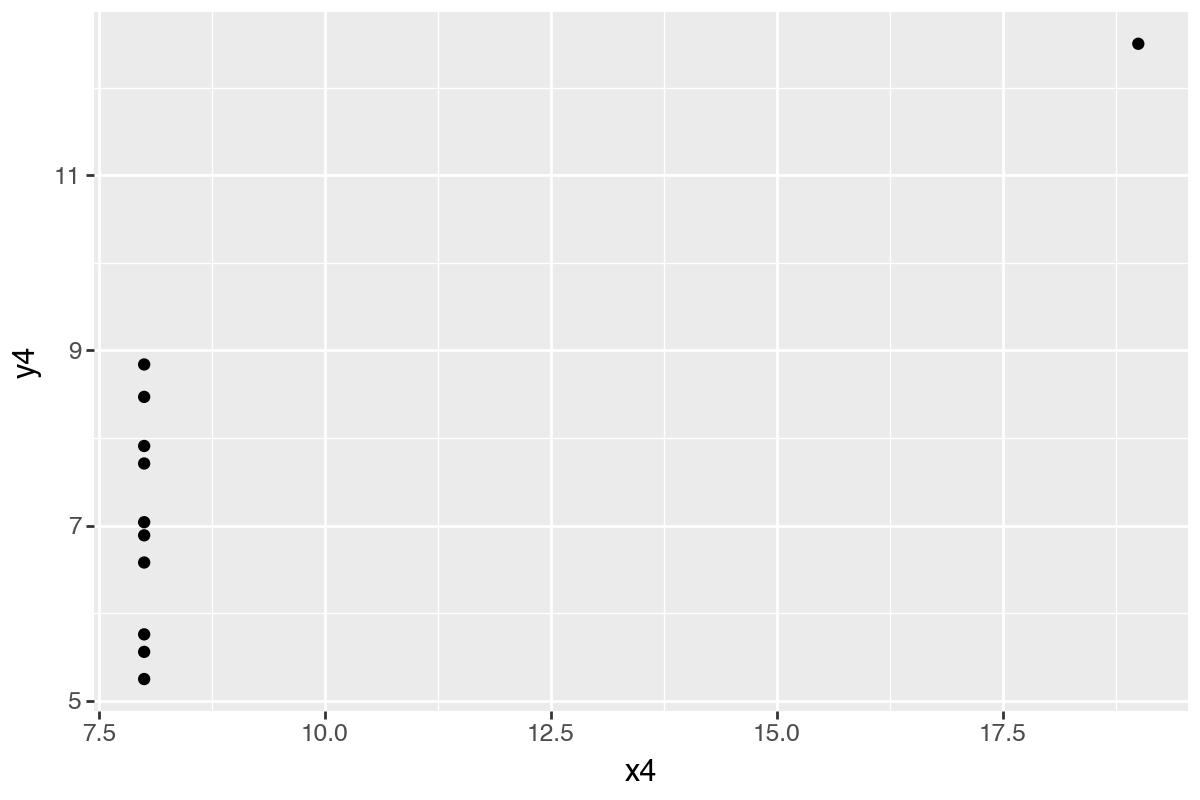

In [135]:
(
    ggplot(Anscombe_quintet, aes(x = 'x4', y = 'y4')) + 
    geom_point() +
    theme(figure_size=(6,4))
)

In [137]:
pearsonr(Anscombe_quintet['x4'], Anscombe_quintet['y4']).pvalue

np.float64(0.0021646023471972357)

We see there is a high Pearson correlation between $X$ and $Y$.

Furthermore, if we use a significance level $\alpha = 0.05$
, we reject the null hypothesis that $H_0: r = 0$
 and conclude there is a statistically significant association between $X$
 and $Y$
. 

The plot however tells us this is driven by a single outlier. The data is probably not Gaussian.

------

### Spearman’s Correlation Coefficient

Spearman’s correlation (or rank-correlation, denoted $\rho$
) addresses those issues by computing the correlation not on the original scale but on rank-transformed values.

To compute $\rho$, we rank the variables $X$
 and $Y$
 separately, yielding rankings such as:

 $x_7 < x_3 < x_5 < x_1 < ...$

 and 

 $y_3 < y_5 < y_11 < y4 < ...$

 We then compute the position of each data point in the ranking, yielding the transformed dataset:

 $rank_x(X),rank_y(Y) = ( (rank_x(x_1), rank_y(y_1))\quad, ... ,\quad (rank_x(x_n), rank_y(y_n)) )$

 For the rankings above, we would have for example that

$(rank_x(x_7), rank_y(y_7)) = (1,3)$

Spearman’s $\rho$ is then computed as the Pearson correlation of the rank-transformed data.

In Python we can compute it using:

In [139]:
Anscombe_quintet['x4'].rank().corr(Anscombe_quintet['y4'].rank(), method= 'pearson')

np.float64(0.5)

Or more directly, by specifying method=“spearman”.

In [141]:
Anscombe_quintet['x4'].corr(Anscombe_quintet['y4'], method= 'spearman')

np.float64(0.5)

#### The Test

Based on the Spearman correlation, we can also define a test for the relationship between two variables.

This test does not make distributional assumptions.

The null hypothesis is:

$H_0: \text{The population rank-correlation is } 0$

In Python you can use function `spearmanr` (analogous to `pearsonr`). Applied to the Anscombe’s dataset we get:

In [144]:
from scipy.stats import spearmanr

spearmanr(df['x'], df['tan_x']) 

SignificanceResult(statistic=np.float64(0.9999999999999999), pvalue=np.float64(0.0))

We see that the Spearman test would not reject, which makes sense, as the rank is less likely to be mislead by the outlier data point. Generally, the Spearman test is less powerful than Pearson when the data is actually Gaussian, but it is more robust to outliers and captures monotonic, yet non-linear, relationships. In practice, the Spearman test is often used.

## Overview

<img src = 'images/Analytical Statistical Assessment (3).png' width = 800>

-------
-------

# Analytical Confidence intervals

Remember the definition of confidence intervals: A confidence interval of <u><b>confidence level</b></u> $1 - \alpha$
 for a parameter $\theta$
 is an interval, which would the data generation process be repeated, would contain the parameter with probability $1-\alpha$
.

For instance, a $95\%$ confidence interval for the expectation $\mu$
, would be an interval $[a,b]$ such that:

$p(a \leq \mu \leq b) = 0.95$


Remember also that here, $a$
 and $b$
 are random, $\mu$ 
 is not!

We have seen how to approximate confidence intervals using the case-resampling bootstrap in the previous chapter. But, confidence intervals can also be computed analytically under some assumptions. We will see this in detail for the binomial case first.

## Binomial Case

We use the same setup as previously:

* We make $N$ independent random tosses of a coin.

* $X_i$: the value of the i-th toss. $\quad X_i = 1 \rarr \text{head}$ || $\quad X_i = 0 \rarr \text{tail}$

* $\mu = E(X_i) = p(X_i = 1)$ the probability of getting a head (same for all tosses).

The sample mean is then given by:

$\bar{X} = \frac{1}{N} \sum_i X_i$

And the estimated standard deviation is given by:

$\hat{SE}(\bar{X}) = \sqrt{\frac{\bar{X}(1-\bar{X})}{N}}$